In [19]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import joblib

# Loading Data and Exploration

In [2]:
df = pd.read_csv("dataset_small__(11_nodes).csv")

In [3]:
df.dtypes
df.describe()
#df.info()
#df.head()

,from_node,to_node,distance_km,time_of_day,traffic_factor,road_type,vehicle_load_pct,weather_condition,travel_time_mins
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,5.434000,5.541000,25.740927,12.549333,1.234707,0.862000,50.486033,0.707333,51.305983
std,3.418509,3.392269,11.283866,4.014342,0.299008,0.792779,28.999343,0.952531,38.286033
min,0.000000,0.000000,1.800000,6.000000,0.700000,0.000000,0.000000,0.000000,1.000000
25%,3.000000,3.000000,17.410000,9.000000,0.980000,0.000000,26.075000,0.000000,23.680000
50%,5.000000,6.000000,23.670000,13.000000,1.120000,1.000000,50.750000,0.000000,40.655000
75%,8.000000,8.000000,34.040000,16.000000,1.530000,2.000000,75.300000,1.000000,69.535000
max,11.000000,11.000000,53.310000,19.000000,1.750000,2.000000,100.000000,3.000000,263.220000


array([[<Axes: title={'center': 'from_node'}>,
        <Axes: title={'center': 'to_node'}>,
        <Axes: title={'center': 'distance_km'}>],
       [<Axes: title={'center': 'time_of_day'}>,
        <Axes: title={'center': 'traffic_factor'}>,
        <Axes: title={'center': 'road_type'}>],
       [<Axes: title={'center': 'vehicle_load_pct'}>,
        <Axes: title={'center': 'weather_condition'}>,
        <Axes: title={'center': 'travel_time_mins'}>]], dtype=object)

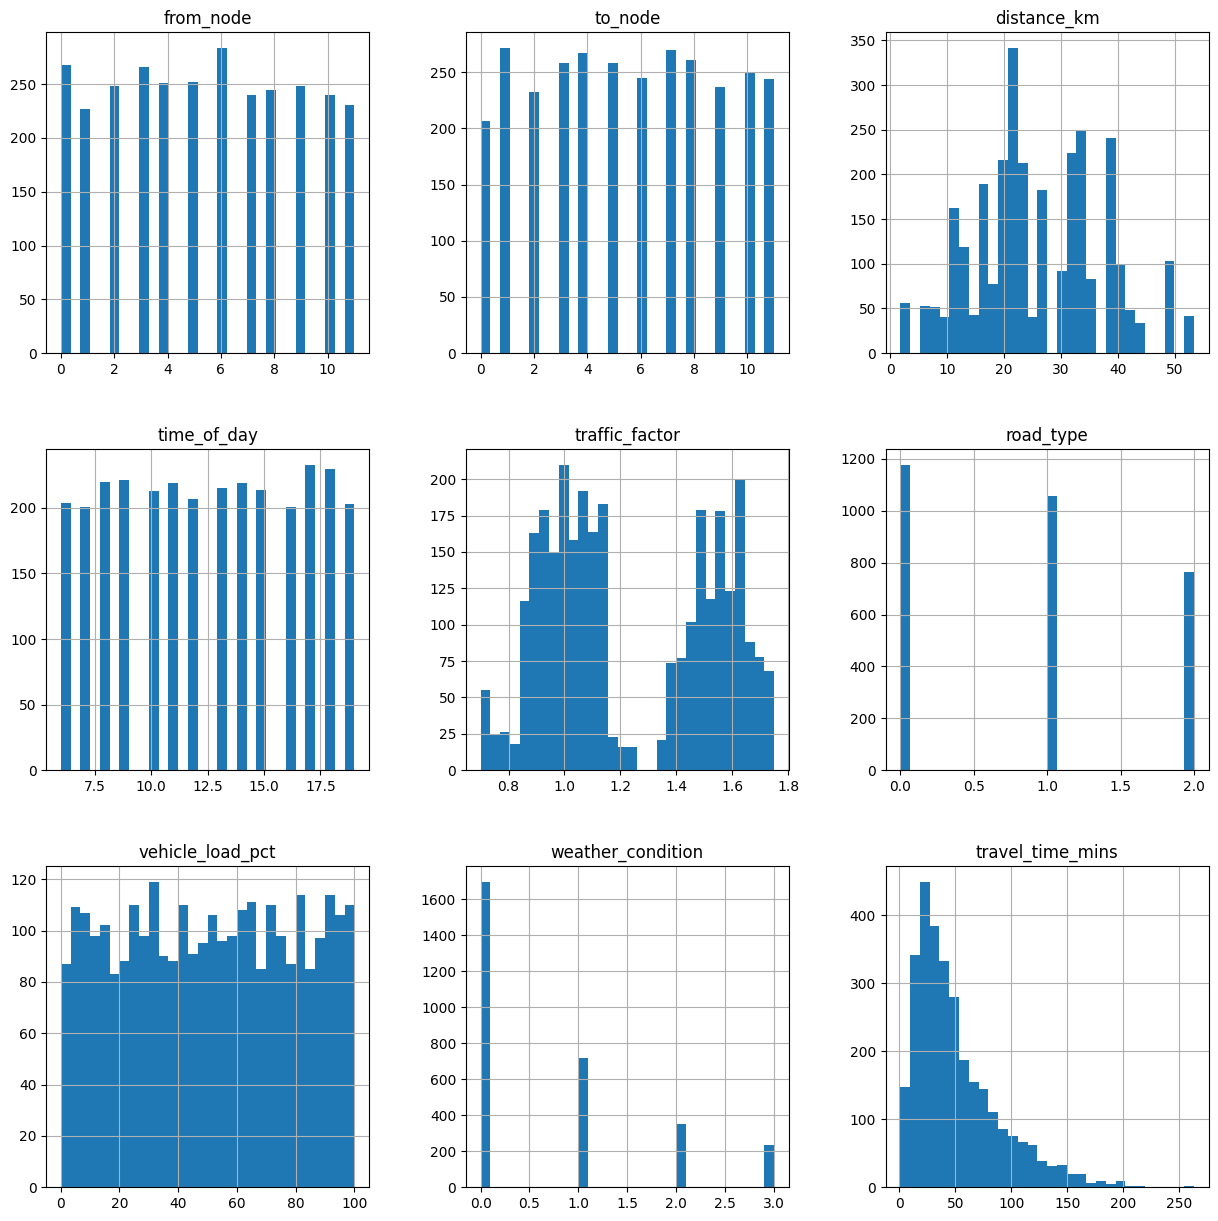

In [4]:
df.hist(bins = 30, figsize = (15,15))

In [5]:
corr_matrix = df.corr().drop('travel_time_mins')
corr_matrix['travel_time_mins'].sort_values(ascending = False).round(3)

distance_km          0.569
traffic_factor       0.263
weather_condition    0.172
vehicle_load_pct     0.026
from_node            0.019
time_of_day         -0.033
to_node             -0.035
road_type           -0.596
Name: travel_time_mins, dtype: float64

## Preprocessing

In [6]:
X = df.drop('travel_time_mins',axis = 1)
y = df['travel_time_mins']

In [7]:
missing = X.isnull().any().sum()
if missing > 0:
    X = X.fillna(X.median(),inplace = True)
    print(f"Filled with columns median value")
else:
    print(f"No empty cell found")

No empty cell found


In [8]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled,columns = X.columns)

# Split Data into Train and Test

In [9]:
from sklearn.model_selection import train_test_split

X_train,X_test, y_train,y_test = train_test_split(X_scaled,y,test_size=0.2, random_state = 42)

# Training Model (Simple Linear Regression)

In [10]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


##### Testing on some random values.

In [11]:
random_x = X_train.iloc[:5]
random_y = y_train.iloc[:5]
print(f"Predictions:{lin_reg.predict(random_x).round(2)}")
print(f"Actual:     {list(random_y)}")

Predictions:[62.49 30.33 42.58 32.71 24.94]
Actual:     [63.26, 26.93, 32.64, 28.73, 18.3]


# Evaluation of the Model

In [14]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score,mean_squared_error

In [15]:
y_pred = lin_reg.predict(X_test)
 
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f"\n  MAE  (Mean Absolute Error)       : {mae:.4f} minutes")
print(f"       → predictions off by {mae:.2f} mins on average")
print(f"\n  RMSE (Root Mean Squared Error)   : {rmse:.4f} minutes")
print(f"       → large errors penalised, {rmse:.2f} mins spread")
print(f"\n  R²   (Coefficient of Determination): {r2:.4f}")


  MAE  (Mean Absolute Error)       : 12.6219 minutes
       → predictions off by 12.62 mins on average

  RMSE (Root Mean Squared Error)   : 17.2570 minutes
       → large errors penalised, 17.26 mins spread

  R²   (Coefficient of Determination): 0.8117


## Cross Validation

In [16]:
# Cross-validation score (more robust evaluation)
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(lin_reg, X_train, y_train,cv=4, scoring="r2")

print(f"\n  4-Fold Cross-Validation R²:")
print(f"    Scores : {[round(s, 4) for s in cv_scores]}")
print(f"    Mean   : {cv_scores.mean():.4f}")
print(f"    Std    : {cv_scores.std():.4f}")


  4-Fold Cross-Validation R²:
    Scores : [np.float64(0.7777), np.float64(0.7958), np.float64(0.8033), np.float64(0.8145)]
    Mean   : 0.7978
    Std    : 0.0134



------------------------------------------------------------
STEP 7: Visualising Results
------------------------------------------------------------
  Saved: linear_regression_evaluation.png


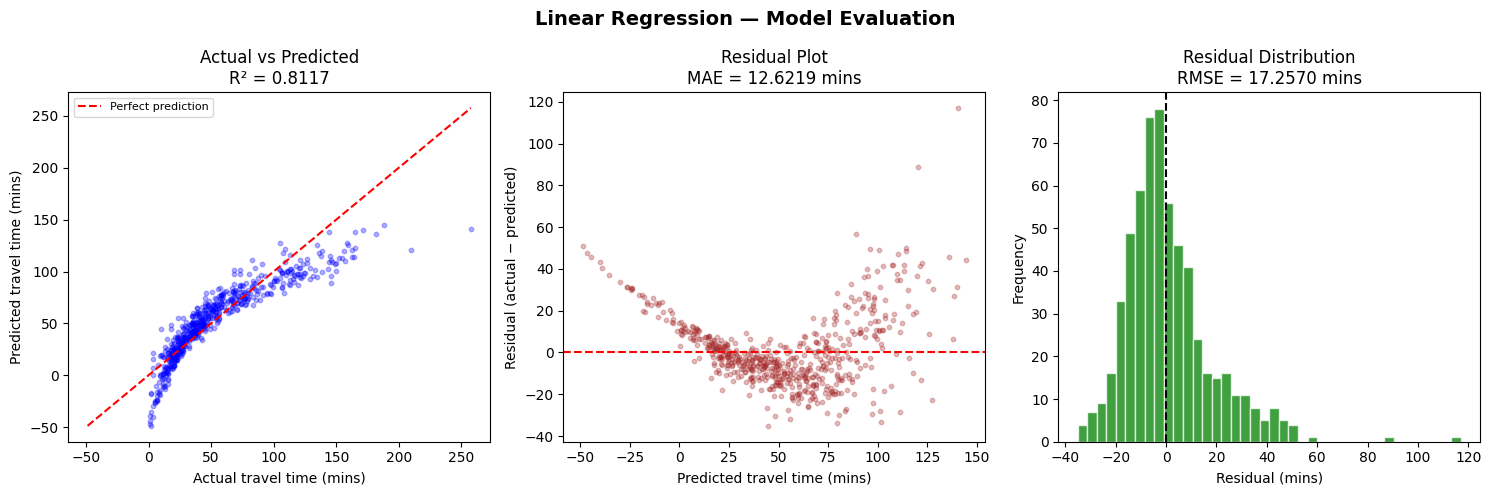

In [17]:
print("\n" + "-"*60)
print("STEP 7: Visualising Results")
print("-"*60)
 
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Linear Regression — Model Evaluation", fontsize=14, fontweight="bold")
 
# Plot 1: Actual vs Predicted
ax[0].scatter(y_test, y_pred, alpha=0.3, s=10, color="blue")
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
ax[0].plot([min_val, max_val], [min_val, max_val], "r--", lw=1.5, label="Perfect prediction")
ax[0].set_xlabel("Actual travel time (mins)")
ax[0].set_ylabel("Predicted travel time (mins)")
ax[0].set_title(f"Actual vs Predicted\nR² = {r2:.4f}")
ax[0].legend(fontsize=8)
 
# Plot 2: Residuals (errors)
residuals = y_test - y_pred
ax[1].scatter(y_pred, residuals, alpha=0.3, s=10, color="brown")
ax[1].axhline(0, color="red", linestyle="--", lw=1.5)
ax[1].set_xlabel("Predicted travel time (mins)")
ax[1].set_ylabel("Residual (actual − predicted)")
ax[1].set_title(f"Residual Plot\nMAE = {mae:.4f} mins")
 
# Plot 3: Residual distribution
ax[2].hist(residuals, bins=40, color="green", alpha=0.75, edgecolor="white")
ax[2].axvline(0, color="black", linestyle="--", lw=1.5)
ax[2].set_xlabel("Residual (mins)")
ax[2].set_ylabel("Frequency")
ax[2].set_title(f"Residual Distribution\nRMSE = {rmse:.4f} mins")
 
plt.tight_layout()
plt.savefig("linear_regression_evaluation.png", dpi=150, bbox_inches="tight")
print("  Saved: linear_regression_evaluation.png")
plt.show()


In [21]:
# ============================================================
# STEP 9 — SAVE THE MODEL
# ============================================================

print("\n" + "-"*60)
print("STEP 9: Saving Model")
print("-"*60)

joblib.dump(lin_reg, "linear_model.pkl")

print("  Saved: linear_model.pkl")



------------------------------------------------------------
STEP 9: Saving Model
------------------------------------------------------------
  Saved: linear_model.pkl
